# Personalized Beauty Product Recommendation System

This project develops a Personalized Beauty Product Recommendation System using Machine Learning techniques, Content-Based Filtering, Collaborative Filtering, and Matrix Factorization.

The main objective is to recommend beauty and skincare products that are relevant to each customer based on product characteristics, customer preferences, and historical review patterns, improving personalization and the overall shopping experience.

Recommendation systems are widely used by companies such as Sephora, L'Oréal, Amazon, and other e-commerce platforms to increase customer engagement, improve product discovery, and support data-driven marketing strategies.

The dataset used in this project is the Sephora Products and Skincare Reviews Dataset, which contains detailed information about beauty products, including categories, brands, prices, ratings, ingredients, customer reviews, and product popularity indicators.

# Libraries Used

This project uses Python libraries for data manipulation, visualization, recommendation modeling, similarity analysis, matrix factorization, and model evaluation.

- Pandas and NumPy for data manipulation and numerical operations
- Matplotlib for data visualization
- Scikit-learn for feature engineering, similarity calculations, train-test split, RMSE, and MAE
- TF-IDF Vectorization for product content representation
- Cosine Similarity for Content-Based and Collaborative Filtering recommendations
- SciPy for Matrix Factorization using Singular Value Decomposition

# Project Steps

- Data Loading
- Initial Data Exploration
- Dataset Integration
- Missing Values and Statistical Summary
- Exploratory Data Analysis
- Data Cleaning and Preprocessing
- Feature Engineering
- Product Popularity Analysis
- User-Product Matrix Creation
- Sparsity Analysis
- Popularity-Based Recommendation
- Content-Based Recommendation
- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering
- Matrix Factorization with SVD
- Recommendation Generation
- Model Evaluation
- RMSE and MAE Analysis
- Model Performance Comparison
- Business Insights and Conclusions

# Import Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from scipy.sparse.linalg import svds

import warnings
warnings.filterwarnings("ignore")



# Data Loading

Loading product information and customer review datasets used to build the recommendation system.

In [33]:
products = pd.read_csv(r"..\data\product_info.csv")
products.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [34]:
review_files = [
    r"..\data\reviews_0-250.csv",
    r"..\data\reviews_250-500.csv",
    r"..\data\reviews_500-750.csv",
    r"..\data\reviews_750-1250.csv",
    r"..\data\reviews_1250-end.csv"
]

reviews_list = []

for file in review_files:
    temp_df = pd.read_csv(file, low_memory=False)
    reviews_list.append(temp_df)
    
reviews = pd.concat(reviews_list, ignore_index = True)

reviews.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


# Initial Data Exploration

Exploring the dataset structure, variables, and key characteristics before data preprocessing and analysis.

In [35]:
print("Products shape:", products.shape)
print("Reviews shape:", reviews.shape)

Products shape: (8494, 27)
Reviews shape: (1094411, 19)


In [36]:
products.columns.tolist()

['product_id',
 'product_name',
 'brand_id',
 'brand_name',
 'loves_count',
 'rating',
 'reviews',
 'size',
 'variation_type',
 'variation_value',
 'variation_desc',
 'ingredients',
 'price_usd',
 'value_price_usd',
 'sale_price_usd',
 'limited_edition',
 'new',
 'online_only',
 'out_of_stock',
 'sephora_exclusive',
 'highlights',
 'primary_category',
 'secondary_category',
 'tertiary_category',
 'child_count',
 'child_max_price',
 'child_min_price']

In [37]:
reviews.columns.tolist()

['Unnamed: 0',
 'author_id',
 'rating',
 'is_recommended',
 'helpfulness',
 'total_feedback_count',
 'total_neg_feedback_count',
 'total_pos_feedback_count',
 'submission_time',
 'review_text',
 'review_title',
 'skin_tone',
 'eye_color',
 'skin_type',
 'hair_color',
 'product_id',
 'product_name',
 'brand_name',
 'price_usd']

In [38]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   str    
 1   product_name        8494 non-null   str    
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   str    
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   str    
 8   variation_type      7050 non-null   str    
 9   variation_value     6896 non-null   str    
 10  variation_desc      1250 non-null   str    
 11  ingredients         7549 non-null   str    
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new              

In [39]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 19 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Unnamed: 0                1094411 non-null  int64  
 1   author_id                 1094411 non-null  str    
 2   rating                    1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   helpfulness               532819 non-null   float64
 5   total_feedback_count      1094411 non-null  int64  
 6   total_neg_feedback_count  1094411 non-null  int64  
 7   total_pos_feedback_count  1094411 non-null  int64  
 8   submission_time           1094411 non-null  str    
 9   review_text               1092967 non-null  str    
 10  review_title              783757 non-null   str    
 11  skin_tone                 923872 non-null   str    
 12  eye_color                 884783 non-null   str    
 13  skin_type                 982854 non-n

# Dataset Integration

Merging product and review information to create a unified dataset for exploratory analysis.

In [40]:
df = reviews.merge(products, on="product_id", how="left", suffixes=("_review", "_product"))

df.head()

,Unnamed: 0,author_id,rating_review,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,1,0,0,['Clean at Sephora'],Skincare,Cleansers,NaN,0,NaN,NaN
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0


In [41]:
df.shape

(1094411, 45)

# Missing Values and Statistical Summary

Checking missing values and analyzing the statistical distribution of numerical variables.

In [42]:
missing_values = df.isnull().sum().sort_values(ascending = False)

missing_values.head(20)

variation_desc       1086128
sale_price_usd       1084658
value_price_usd      1063534
child_min_price       641008
child_max_price       641008
helpfulness           561592
review_title          310654
hair_color            226768
eye_color             209628
skin_tone             170539
is_recommended        167988
tertiary_category     161256
highlights            113936
skin_type             111557
variation_value        63433
variation_type         51455
size                   43363
ingredients            22025
review_text             1444
author_id                  0
dtype: int64

In [43]:
df.describe()

,Unnamed: 0,rating_review,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,price_usd_review,brand_id,loves_count,...,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,child_count,child_max_price,child_min_price
count,1.094411e+06,1.094411e+06,926423.000000,532819.000000,1.094411e+06,1.094411e+06,1.094411e+06,1.094411e+06,1.094411e+06,1.094411e+06,...,30877.000000,9753.000000,1.094411e+06,1.094411e+06,1.094411e+06,1.094411e+06,1.094411e+06,1.094411e+06,453403.000000,453403.000000
mean,1.989864e+05,4.299158e+00,0.839962,0.767782,4.177126e+00,8.948695e-01,3.282257e+00,4.900838e+01,5.548418e+03,1.068615e+05,...,115.147053,16.839300,1.677797e-02,2.654304e-02,1.099633e-01,3.154939e-02,3.242301e-01,7.726585e-01,58.278683,30.272535
std,1.749886e+05,1.149444e+00,0.366642,0.317164,2.271524e+01,5.288943e+00,1.967482e+01,4.004338e+01,1.492132e+03,1.677102e+05,...,62.168899,13.929354,1.284387e-01,1.607437e-01,3.128441e-01,1.747972e-01,4.680867e-01,1.260349e+00,62.066098,28.761763
min,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,1.063000e+03,0.000000e+00,...,20.000000,3.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000,3.000000
25%,5.590600e+04,4.000000e+00,1.000000,0.652174,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e+01,5.626000e+03,1.665600e+04,...,68.000000,7.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,21.000000,17.000000
50%,1.308240e+05,5.000000e+00,1.000000,0.928571,0.000000e+00,0.000000e+00,0.000000e+00,3.900000e+01,6.073000e+03,4.873900e+04,...,102.000000,18.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,40.000000,22.000000
75%,3.285265e+05,5.000000e+00,1.000000,1.000000,3.000000e+00,1.000000e+00,3.000000e+00,6.200000e+01,6.234000e+03,1.234390e+05,...,142.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,71.000000,30.000000
max,6.021290e+05,5.000000e+00,1.000000,1.000000,5.464000e+03,1.159000e+03,5.050000e+03,1.900000e+03,8.017000e+03,1.081315e+06,...,480.000000,320.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.300000e+01,570.000000,365.000000


# Exploratory Data Analysis

Analyzing product ratings, prices, brands, categories, customer reviews, and product popularity patterns.

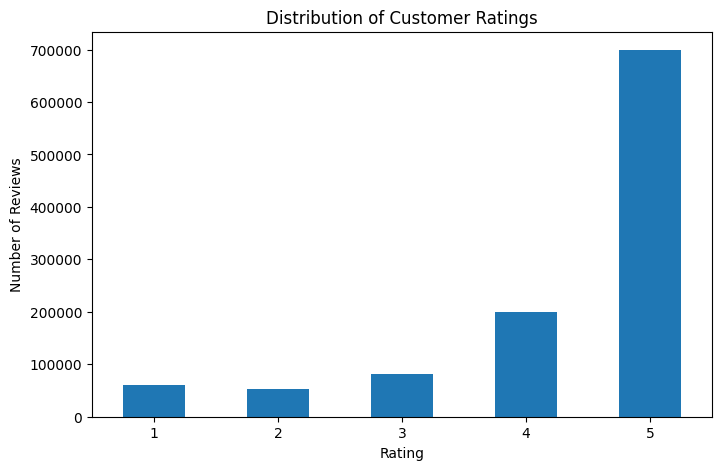

In [44]:
# Rating distribution from customer reviews
plt.figure(figsize=(8,5))

reviews["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

The rating distribution is heavily concentrated in ratings 4 and 5, indicating that most customers report positive experiences with beauty and skincare products.

Rating 5 represents the majority of reviews, suggesting a high overall level of customer satisfaction across the platform. Lower ratings are significantly less frequent, which may indicate strong product quality or customer loyalty toward beauty brands.

This positive rating trend can influence recommendation systems, as highly rated products are more likely to be suggested to customers.

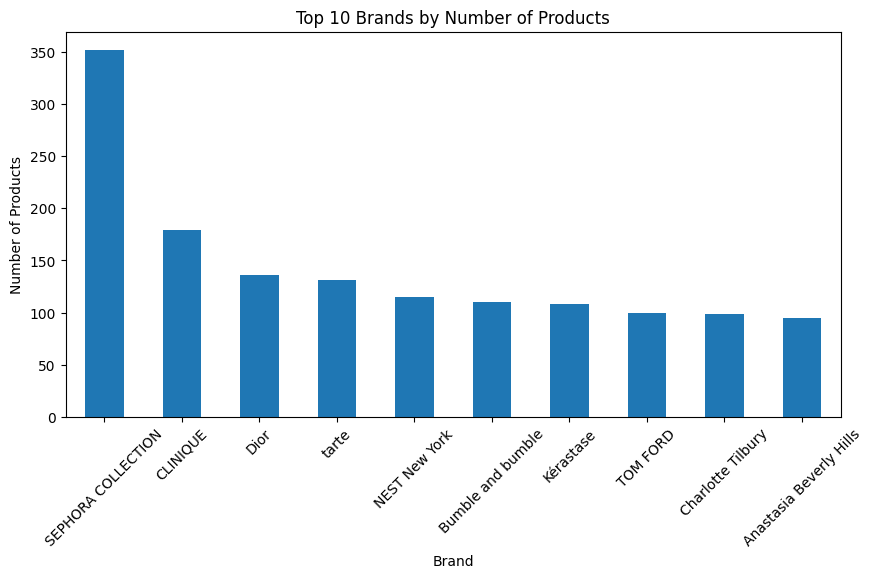

In [45]:
# Top 10 Brands by number of products
top_brands = products["brand_name"].value_counts().head(10)

plt.figure(figsize = (10,5))

top_brands.plot(kind = "bar")

plt.title("Top 10 Brands by Number of Products")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation = 45)

plt.show()

The analysis reveals a strong concentration of products among a few major beauty brands.

SEPHORA COLLECTION stands out as the brand with the largest product portfolio in the dataset, offering approximately twice as many products as the second-ranked brand, CLINIQUE. This reflects Sephora's strategy of maintaining a broad product offering across multiple beauty categories.

Other well-established brands such as Dior, Tarte, NEST New York, Bumble and bumble, Kérastase, TOM FORD, Charlotte Tilbury, and Anastasia Beverly Hills also show significant representation within the platform.

The concentration of products among these brands may influence recommendation results, as brands with larger catalogs have a greater likelihood of appearing in customer interactions and recommendation outputs.

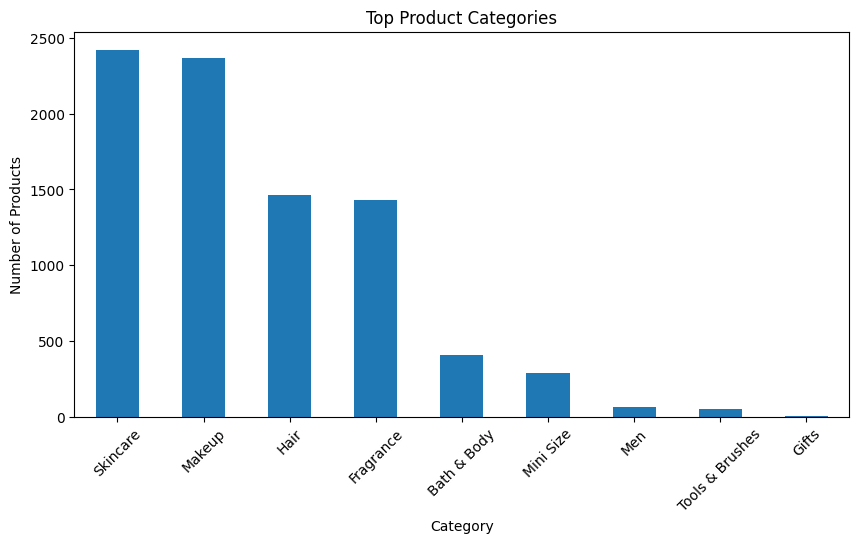

In [46]:
# Top product categories
top_categories = products["primary_category"].value_counts().head(10)

plt.figure(figsize = (10,5))

top_categories.plot(kind="bar")

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation = 45)

plt.show()

The category analysis reveals that Skincare and Makeup dominate the product catalog, each representing more than 2,300 products. This highlights the strong consumer demand and strategic importance of these categories within the beauty industry.

Hair care and Fragrance products form a second tier of highly represented categories, with approximately 1,400 products each, demonstrating the diversity of beauty offerings available on the platform.

In contrast, categories such as Bath & Body, Mini Size, Men, Tools & Brushes, and Gifts contain considerably fewer products, indicating a more specialized market focus.

These findings suggest that recommendation systems operating in the beauty industry should prioritize Skincare and Makeup products due to their large product variety and high potential for customer interactions. Additionally, category information can play an important role in improving recommendation relevance by aligning suggestions with customer interests and shopping behavior.

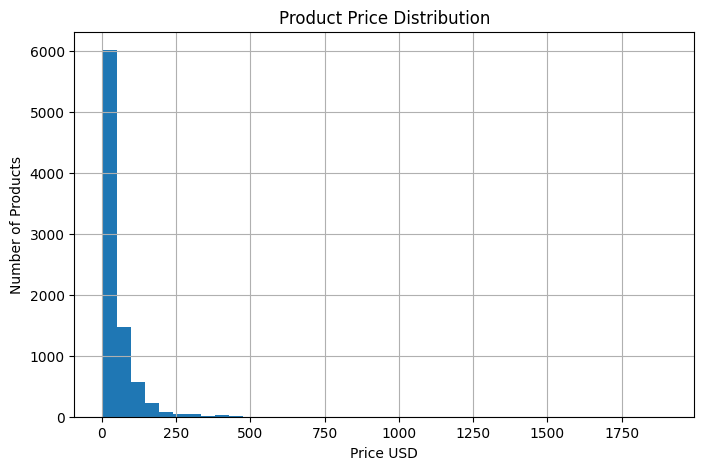

In [47]:
# Price distribution
plt.figure(figsize=(8, 5))

products["price_usd"].dropna().hist(bins=40)

plt.title("Product Price Distribution")
plt.xlabel("Price USD")
plt.ylabel("Number of Products")

plt.show()

The product price distribution is highly right-skewed, indicating that most beauty products are concentrated in the lower price ranges, while only a small number of products belong to premium and luxury segments.

The majority of products are priced below approximately USD 100, suggesting that the platform primarily serves customers seeking affordable and mid-range beauty products. As product prices increase, the number of available products decreases significantly.

A small number of high-end products with prices exceeding USD 500 are also present in the catalog, demonstrating that the platform offers products targeting multiple customer segments, from mass-market consumers to luxury beauty shoppers.

These findings highlight the importance of incorporating price information into recommendation systems, as customer preferences are often influenced by budget constraints and purchasing power.

# Data Cleaning and Preprocessing

Preparing product and review data by selecting relevant columns, handling missing values, and removing duplicates.

In [48]:
product_column = [
    "product_id",
    "product_name",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "rating",
    "reviews",
    "loves_count",
    "price_usd",
    "ingredients",
    "highlights"
]

product_df = products[product_column].copy()

product_df.head()

,product_id,product_name,brand_name,primary_category,secondary_category,tertiary_category,rating,reviews,loves_count,price_usd,ingredients,highlights
0,P473671,Fragrance Discovery Set,19-69,Fragrance,Value & Gift Sets,Perfume Gift Sets,3.6364,11.0,6320,35.0,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...","['Unisex/ Genderless Scent', 'Warm &Spicy Scen..."
1,P473668,La Habana Eau de Parfum,19-69,Fragrance,Women,Perfume,4.1538,13.0,3827,195.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","['Unisex/ Genderless Scent', 'Layerable Scent'..."
2,P473662,Rainbow Bar Eau de Parfum,19-69,Fragrance,Women,Perfume,4.2500,16.0,3253,195.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","['Unisex/ Genderless Scent', 'Layerable Scent'..."
3,P473660,Kasbah Eau de Parfum,19-69,Fragrance,Women,Perfume,4.4762,21.0,3018,195.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","['Unisex/ Genderless Scent', 'Layerable Scent'..."
4,P473658,Purple Haze Eau de Parfum,19-69,Fragrance,Women,Perfume,3.2308,13.0,2691,195.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","['Unisex/ Genderless Scent', 'Layerable Scent'..."


In [49]:
text_columns = [
    "product_name",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "ingredients",
    "highlights"
]

for col in text_columns:
    product_df[col] = product_df[col].fillna("")
    
product_df["rating"] = product_df["rating"].fillna(product_df["rating"].median())
product_df["reviews"] = product_df["reviews"].fillna(0)
product_df["loves_count"] = product_df["loves_count"].fillna(0)
product_df["price_usd"] = product_df["price_usd"].fillna(product_df["price_usd"].median())

product_df = product_df.drop_duplicates(subset="product_id")

product_df.isnull().sum()

product_id            0
product_name          0
brand_name            0
primary_category      0
secondary_category    0
tertiary_category     0
rating                0
reviews               0
loves_count           0
price_usd             0
ingredients           0
highlights            0
dtype: int64

In [50]:
review_df = reviews[[
    "author_id",
    "product_id",
    "rating"
]].copy()

review_df = review_df.dropna()
review_df = review_df.drop_duplicates(subset = ["author_id", "product_id"])

review_df.head()

,author_id,product_id,rating
0,1741593524,P504322,5
1,31423088263,P420652,1
2,5061282401,P420652,5
3,6083038851,P420652,5
4,47056667835,P420652,5


# Feature Engineering

Creating new variables and combining product information into a single text feature for similarity-based recommendations.

In [51]:
def price_range(price):
    if price <= 25:
        return "Low Price"
    elif price <= 60:
        return "Medium Price"
    else:
        return "High Price"
    
product_df["price_range"] = product_df["price_usd"].apply(price_range)

In [52]:
product_df["combined_features"] = (
    product_df["product_name"] + " " +
    product_df["brand_name"] + " " +
    product_df["primary_category"] + " " +
    product_df["secondary_category"] + " " +
    product_df["tertiary_category"] + " " +
    product_df["ingredients"] + " " +
    product_df["highlights"] + " " +
    product_df["price_range"]
)

product_df[["product_name", "combined_features"]].head()

,product_name,combined_features
0,Fragrance Discovery Set,Fragrance Discovery Set 19-69 Fragrance Value ...
1,La Habana Eau de Parfum,La Habana Eau de Parfum 19-69 Fragrance Women ...
2,Rainbow Bar Eau de Parfum,Rainbow Bar Eau de Parfum 19-69 Fragrance Wome...
3,Kasbah Eau de Parfum,Kasbah Eau de Parfum 19-69 Fragrance Women Per...
4,Purple Haze Eau de Parfum,Purple Haze Eau de Parfum 19-69 Fragrance Wome...


# Product Popularity Analysis

Identifying the most popular products based on ratings, reviews, and customer engagement indicators.

In [53]:
most_loved = product_df.sort_values(
    by="loves_count",
    ascending=False
)[[
    "product_name",
    "brand_name",
    "primary_category",
    "rating",
    "loves_count",
    "price_usd"
]].head(10)

most_loved

,product_name,brand_name,primary_category,rating,loves_count,price_usd
6242,Soft Pinch Liquid Blush,Rare Beauty by Selena Gomez,Makeup,4.5356,1401068,23.0
5249,Radiant Creamy Concealer,NARS,Makeup,4.3080,1153594,32.0
4431,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,Skincare,4.3508,1081315,24.0
6434,Cream Lip Stain Liquid Lipstick,SEPHORA COLLECTION,Makeup,4.3201,1029051,15.0
2523,Gloss Bomb Universal Lip Luminizer,Fenty Beauty by Rihanna,Makeup,4.6357,968317,21.0
2524,Pro Filt’r Soft Matte Longwear Liquid Foundation,Fenty Beauty by Rihanna,Makeup,4.0356,856497,40.0
5250,Blush,NARS,Makeup,4.6643,840076,32.0
247,Brow Wiz Ultra-Slim Precision Brow Pencil,Anastasia Beverly Hills,Makeup,4.4056,834189,25.0
4458,Translucent Loose Setting Powder,Laura Mercier,Makeup,4.5029,813497,43.0
7648,Niacinamide 10% + Zinc 1% Oil Control Serum,The Ordinary,Skincare,4.2439,763168,6.0


The most loved products are primarily concentrated in the Makeup and Skincare categories, highlighting the strong customer engagement within these segments.

Rare Beauty's Soft Pinch Liquid Blush stands out as the most popular product in the dataset, receiving more than 1.4 million customer favorites. Other highly loved products from NARS, Fenty Beauty, LANEIGE, and The Ordinary also demonstrate exceptional customer engagement and brand loyalty.

Interestingly, both premium and affordable products appear among the most loved items. For example, The Ordinary's Niacinamide 10% + Zinc 1% Serum achieved over 760 thousand favorites despite having a relatively low price point of USD 6. This suggests that product popularity is influenced not only by price, but also by perceived effectiveness, brand reputation, and customer satisfaction.

These findings indicate that Makeup and Skincare products play a central role in customer preferences and represent strong candidates for popularity-based recommendation strategies, particularly for new users with limited interaction history.

In [54]:
top_rated = product_df[
    product_df["reviews"] >= 100
].sort_values(
    by=["rating", "reviews"],
    ascending=False
)[[
    "product_name",
    "brand_name",
    "primary_category",
    "rating",
    "reviews",
    "price_usd"
]].head(10)

top_rated

,product_name,brand_name,primary_category,rating,reviews,price_usd
730,Rapid Repair Hair Mask,BondiBoost,Hair,4.9937,158.0,29.95
744,Heavenly Hydration Hair Mask,BondiBoost,Hair,4.9818,110.0,29.99
8320,Sparkling Cuvee Glass Jar Candle,VOLUSPA,Fragrance,4.9648,142.0,34.00
737,Blonde Baby Hydrating Toning Purple Conditioner,BondiBoost,Hair,4.9518,228.0,29.95
745,Frizz Fix Serum,BondiBoost,Hair,4.9412,119.0,23.99
723,Hair Thickening Therapy Mask,BondiBoost,Hair,4.9249,253.0,29.95
725,Elixir Hair Oil Treatment with Castor Oil,BondiBoost,Hair,4.9211,266.0,19.95
7314,Lucea 1 ½” Professional Straightening and Styl...,T3,Hair,4.9179,195.0,189.99
7321,Smooth ID 1” Digital Ceramic Flat Iron with Sm...,T3,Hair,4.9143,105.0,249.00
741,Heavenly Hydration Pre-Shampoo Hair Oil,BondiBoost,Hair,4.9109,101.0,29.99


The highest-rated products are predominantly concentrated in the Hair category, with BondiBoost standing out as the most represented brand among the top-performing products.

Several BondiBoost products achieved ratings above 4.9 stars while maintaining a substantial number of customer reviews, indicating consistently high levels of customer satisfaction and product quality. This combination of excellent ratings and meaningful review volume increases confidence in the reliability of these evaluations.

The presence of both hair care treatments and professional styling tools among the highest-rated products suggests that customers highly value products that deliver visible and measurable results.

Additionally, the appearance of products from different price ranges, from approximately USD 20 to USD 250, indicates that customer satisfaction is not exclusively driven by product cost. Instead, effectiveness, performance, and customer experience appear to play a more significant role in determining product ratings.

These products represent strong candidates for recommendation strategies focused on quality and customer satisfaction, particularly for users seeking highly rated beauty and hair care solutions.

# User-Product Matrix Creation

Creating a matrix where rows represent users, columns represent products, and values represent customer ratings.

In [55]:
product_review_counts = review_df["product_id"].value_counts()
active_products = product_review_counts[product_review_counts >= 20].index

user_review_counts = review_df["author_id"].value_counts()
active_users = user_review_counts[user_review_counts >= 5].index

filtered_reviews = review_df[
    (review_df["product_id"].isin(active_products)) &
    (review_df["author_id"].isin(active_users))
]

filtered_reviews.shape

(369815, 3)

In [56]:
user_product_matrix = filtered_reviews.pivot_table(
    index="author_id",
    columns="product_id",
    values="rating"
)

user_product_matrix.head()

product_id,P107306,P114902,P12045,P122651,P122661,P122718,P122727,P122762,P122767,P122774,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
author_id,,,,,,,,,,,,,,,,,,,,,
10000117144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10000217994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10000290716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10000770719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10000892274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Sparsity Analysis

Measuring how sparse the user-product matrix is, since most customers review only a small portion of all available products.

In [57]:
total_values = user_product_matrix.shape[0] * user_product_matrix.shape[1]
missing_values = user_product_matrix.isnull().sum().sum()
filled_values = total_values - missing_values

sparsity = (missing_values / total_values) * 100

print(f"Total values: {total_values}")
print(f"Filled values: {filled_values}")
print(f"Missing values: {missing_values}")
print(f"Sparsity: {sparsity:.2f}%")

Total values: 78076123
Filled values: 369815
Missing values: 77706308
Sparsity: 99.53%


The user-product matrix presented a sparsity level of approximately 99.53%, meaning that only a very small fraction of all possible user-product interactions contain actual ratings.

Out of more than 78 million possible user-product combinations, only about 370 thousand interactions were recorded. This indicates that most customers review only a limited number of products compared to the size of the overall catalog.

Such a high level of sparsity is a common characteristic of large-scale recommendation systems used by e-commerce and digital platforms. However, it also increases the complexity of generating accurate recommendations, since the model has limited information about many users and products.

# Popularity-Based Recommendation

Creating a baseline recommendation model based on the most popular and highly rated beauty products.

In [26]:
def popularity_based_recommendation(category=None, min_reviews=100, top_n=10):
    data = product_df.copy()
    
    if category:
        data = data[data["primary_category"].str.contains(category, case=False, na=False)]
        
    recommendations = data[data["reviews"] >= min_reviews].sort_values(
        by=["rating", "loves_count", "reviews"],
        ascending=False
    ).head(top_n)
    
    return recommendations[[
        "product_name",
        "brand_name",
        "primary_category",
        "rating",
        "reviews",
        "loves_count",
        "price_usd"
    ]]
    
popularity_based_recommendation(top_n=10)

,product_name,brand_name,primary_category,rating,reviews,loves_count,price_usd
730,Rapid Repair Hair Mask,BondiBoost,Hair,4.9937,158.0,6772,29.95
744,Heavenly Hydration Hair Mask,BondiBoost,Hair,4.9818,110.0,1549,29.99
8320,Sparkling Cuvee Glass Jar Candle,VOLUSPA,Fragrance,4.9648,142.0,1829,34.00
737,Blonde Baby Hydrating Toning Purple Conditioner,BondiBoost,Hair,4.9518,228.0,2632,29.95
745,Frizz Fix Serum,BondiBoost,Hair,4.9412,119.0,1244,23.99
723,Hair Thickening Therapy Mask,BondiBoost,Hair,4.9249,253.0,11214,29.95
725,Elixir Hair Oil Treatment with Castor Oil,BondiBoost,Hair,4.9211,266.0,9613,19.95
7314,Lucea 1 ½” Professional Straightening and Styl...,T3,Hair,4.9179,195.0,4440,189.99
7321,Smooth ID 1” Digital Ceramic Flat Iron with Sm...,T3,Hair,4.9143,105.0,1191,249.00
741,Heavenly Hydration Pre-Shampoo Hair Oil,BondiBoost,Hair,4.9109,101.0,1884,29.99


# Content-Based Recommendation

Building recommendations based on product characteristics such as brand, category, ingredients, benefits, and price range.

In [27]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(product_df["combined_features"])

tfidf_matrix.shape

(8494, 5000)

In [28]:
content_similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

content_similarity.shape

(8494, 8494)

In [29]:
product_indices = pd.Series(
    product_df.index.values,
    index=product_df["product_name"]
)

product_indices = product_indices[~product_indices.index.duplicated(keep="first")]

In [30]:
def content_based_recommendation(product_name, top_n=10):
    if product_name not in product_indices:
        return "Product not found. Please check the product name."
    
    idx = int(product_indices[product_name])
    
    similarity_scores = list(enumerate(content_similarity[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:top_n + 1]
    
    product_indexes = [i[0] for i in similarity_scores]
    scores = [i[1] for i in similarity_scores]
    
    recommendations = product_df.iloc[product_indexes][[
        "product_id",
        "product_name",
        "brand_name",
        "primary_category",
        "rating",
        "price_usd"
    ]].copy()
    
    recommendations["similarity_score"] = scores
    
    return recommendations

content_based_recommendation(product_df["product_name"].iloc[0], top_n=10)

,product_id,product_name,brand_name,primary_category,rating,price_usd,similarity_score
8,P472300,Capri Eau de Parfum,19-69,Fragrance,3.5714,195.0,0.758306
12,P473664,L'air Barbes Eau de Parfum,19-69,Fragrance,3.0000,195.0,0.741877
1,P473668,La Habana Eau de Parfum,19-69,Fragrance,4.1538,195.0,0.737876
3,P473660,Kasbah Eau de Parfum,19-69,Fragrance,4.4762,195.0,0.730187
2,P473662,Rainbow Bar Eau de Parfum,19-69,Fragrance,4.2500,195.0,0.722558
11,P473670,Capri Eau de Parfum Travel Spray,19-69,Fragrance,3.5714,30.0,0.705286
4,P473658,Purple Haze Eau de Parfum,19-69,Fragrance,3.2308,195.0,0.692648
13,P473665,L'air Barbes Eau de Parfum Travel Spray,19-69,Fragrance,3.0000,30.0,0.692481
3826,P500034,Not a Perfume Sampler Set,Juliette Has a Gun,Fragrance,3.3125,28.0,0.673710
3834,P502369,Essential Wardrobe Eau de Parfum Set,Juliette Has a Gun,Fragrance,4.0000,50.0,0.672320


The Content-Based Recommendation model successfully identified products with highly similar characteristics to the selected item.

The recommended products are predominantly concentrated within the Fragrance category, with most recommendations belonging to the same brand (19-69) as the original product. This demonstrates that the TF-IDF and Cosine Similarity approach effectively captures product attributes and textual similarities.

The similarity scores range from approximately 0.67 to 0.76, indicating a strong degree of similarity between the recommended products and the selected fragrance. Products such as Capri Eau de Parfum, L'air Barbes Eau de Parfum, and La Habana Eau de Parfum achieved the highest similarity scores, suggesting that they share common characteristics related to brand identity, product description, and category.

Additionally, the model was able to recommend products from another fragrance brand, Juliette Has a Gun, showing its ability to identify relevant alternatives beyond the original brand while maintaining category consistency.

# User-Based Collaborative Filtering

Building recommendations based on customers with similar rating behavior.

In [31]:
user_product_filled = user_product_matrix.fillna(0)

user_similarity = cosine_similarity(user_product_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index = user_product_filled.index,
    columns = user_product_filled.index
)

user_similarity_df.head()

author_id,10000117144,10000217994,10000290716,10000770719,10000892274,10001606143,10001768414,1000235057,10002646684,10003441511,...,9995173030,9995433396,9995791416,9995948393,9996449006,999660815,9999019570,orderGen1221842,orderGen1698648,orderGen51156
author_id,,,,,,,,,,,,,,,,,,,,,
10000117144,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.062994,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
10000217994,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.280539,0.0,0.0,0.0,0.0,0.0,0.0
10000290716,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.238145,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
10000770719,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
10000892274,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
def user_based_recommendation(user_id, top_n=10):
    if user_id not in user_similarity_df.index:
        return "User not found in the filtered review dataset."
    
    similar_users = user_similarity_df[user_id].sort_values(ascending=False).drop(user_id)
    products_reviewed = user_product_matrix.loc[user_id].dropna().index
    
    recommended_products = pd.Series(dtype=float)
    
    for similar_user_id, similarity_score in similar_users.head(20).items():
        similar_user_ratings = user_product_matrix.loc[similar_user_id].dropna()
        similar_user_ratings = similar_user_ratings.drop(labels=products_reviewed, errors="ignore")
        
        weighted_ratings = similar_user_ratings * similarity_score
        recommended_products = pd.concat([recommended_products, weighted_ratings])
    
    recommended_products = recommended_products.groupby(recommended_products.index).sum()
    recommended_products = recommended_products.sort_values(ascending=False).head(top_n)
    
    recommendations = recommended_products.reset_index()
    recommendations.columns = ["product_id", "recommendation_score"]
    
    recommendations = recommendations.merge(
        product_df[[
            "product_id",
            "product_name",
            "brand_name",
            "primary_category",
            "rating",
            "price_usd"
        ]],
        on="product_id",
        how="left"
    )
    
    return recommendations

sample_user = user_product_matrix.index[0]

user_based_recommendation(sample_user, top_n=10)

,product_id,recommendation_score,product_name,brand_name,primary_category,rating,price_usd
0,P232906,2.584383,Oil Free Moisturizer,Kate Somerville,Skincare,4.1489,76.0
1,P422510,2.535463,Mini Ultra Facial Moisturizing Cream with Squa...,Kiehl's Since 1851,Skincare,4.4469,24.0
2,P421996,2.535463,Ultra Facial Moisturizing Cream with Squalane,Kiehl's Since 1851,Skincare,4.4469,78.0
3,P427413,2.481712,Lactic Acid 10% + HA 2% Exfoliating Serum,The Ordinary,Skincare,4.5035,8.9
4,P94421,2.170438,Vinoperfect Radiance Dark Spot Serum Vitamin C...,Caudalie,Skincare,4.2442,82.0
5,P383053,2.155620,Do Not Age with Dr. Brandt Triple Peptide Eye ...,Dr. Brandt Skincare,Skincare,4.0822,82.0
6,P480447,2.153652,10 + 10 Moisturizer with 10% Vitamin C + 10% P...,iNNBEAUTY PROJECT,Skincare,4.5646,35.0
7,P427417,2.118779,Niacinamide 10% + Zinc 1% Oil Control Serum,The Ordinary,Skincare,4.2439,6.0
8,P427419,2.118779,Hyaluronic Acid 2% + B5 Hydrating Serum,The Ordinary,Skincare,4.2133,15.7
9,P439928,2.118779,Superscreen Daily Moisturizer Sunscreen SPF 40...,Supergoop!,Skincare,3.6997,44.0


# Item-Based Collaborative Filtering

Building recommendations based on similarities between products using customer rating patterns.

In [33]:
item_user_matrix = user_product_matrix.T.fillna(0)

item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()

product_id,P107306,P114902,P12045,P122651,P122661,P122718,P122727,P122762,P122767,P122774,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
product_id,,,,,,,,,,,,,,,,,,,,,
P107306,1.000000,0.012590,0.016431,0.000000,0.003968,0.000000,0.031323,0.003123,0.000000,0.019412,...,0.010999,0.049361,0.017482,0.036166,0.000000,0.028070,0.043727,0.053325,0.048555,0.037273
P114902,0.012590,1.000000,0.018650,0.000000,0.011241,0.050547,0.000000,0.027168,0.003914,0.042572,...,0.008012,0.038285,0.051880,0.022238,0.017857,0.020474,0.018088,0.018222,0.010564,0.018854
P12045,0.016431,0.018650,1.000000,0.005826,0.002147,0.026188,0.000000,0.014994,0.000000,0.011688,...,0.012377,0.074183,0.000000,0.042818,0.008527,0.061310,0.013143,0.008014,0.011581,0.011483
P122651,0.000000,0.000000,0.005826,1.000000,0.074171,0.025942,0.000000,0.016213,0.000000,0.061774,...,0.018731,0.015662,0.007564,0.011705,0.000000,0.000000,0.000000,0.000000,0.001084,0.027953
P122661,0.003968,0.011241,0.002147,0.074171,1.000000,0.150228,0.041950,0.113333,0.077713,0.124794,...,0.000000,0.022771,0.015609,0.033465,0.013508,0.014666,0.030192,0.000000,0.008950,0.000000


In [34]:
def item_based_recommendation(product_id, top_n=10):
    if product_id not in item_similarity_df.index:
        return "Product not found in the filtered review dataset."
    
    similar_products = item_similarity_df[product_id].sort_values(ascending=False).drop(product_id)
    
    recommendations = similar_products.head(top_n).reset_index()
    recommendations.columns = ["product_id", "similarity_score"]
    
    recommendations = recommendations.merge(
        product_df[[
            "product_id",
            "product_name",
            "brand_name",
            "primary_category",
            "rating",
            "price_usd"
        ]],
        on="product_id",
        how="left"
    )
    
    return recommendations

sample_product = item_user_matrix.index[0]

item_based_recommendation(sample_product, top_n=10)

,product_id,similarity_score,product_name,brand_name,primary_category,rating,price_usd
0,P4010,0.094013,AHA/BHA Exfoliating Cleanser,Murad,Skincare,4.4981,46.0
1,P38217,0.092479,Renewing Cleansing Cream,Murad,Skincare,4.4646,45.0
2,P397627,0.089343,Dermask Intra Jet Firming Solution,Dr. Jart+,Skincare,3.3061,9.0
3,P4032,0.087553,Hydrating Toner,Murad,Skincare,4.2934,42.0
4,P4039,0.086290,Perfecting Day Cream Broad Spectrum SPF 30 PA+++,Murad,Skincare,4.1724,65.0
5,P471788,0.083023,Mini AHA/BHA Exfoliating Cleanser,Murad,Skincare,4.4898,17.0
6,P383308,0.078750,Age Arrest Eye Cream,Kate Somerville,Skincare,3.7451,98.0
7,P442263,0.073371,needles no more 3-D LIP PLUMPFIX,Dr. Brandt Skincare,Skincare,2.8947,39.0
8,P455919,0.068908,MenoReverse Volumizing Serum-in-Moisturizer,KORRES,Skincare,4.0517,45.0
9,P377178,0.067909,Rapid Collagen Infusion,Murad,Skincare,4.1280,89.0


# Matrix Factorization with SVD

Applying Singular Value Decomposition to predict customer ratings for products that have not been reviewed yet.

In [35]:
train_data, test_data = train_test_split(
    filtered_reviews,
    test_size=0.2,
    random_state=42
)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (295852, 3)
Test shape: (73963, 3)


In [36]:
train_matrix = train_data.pivot_table(
    index="author_id",
    columns="product_id",
    values="rating"
).fillna(0)

train_matrix.head()

product_id,P107306,P114902,P12045,P122651,P122661,P122718,P122727,P122762,P122767,P122774,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
author_id,,,,,,,,,,,,,,,,,,,,,
10000117144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10000217994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10000290716,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10000770719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10000892274,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
test_data = test_data[
    (test_data["author_id"].isin(train_matrix.index)) &
    (test_data["product_id"].isin(train_matrix.columns))
]

test_data.shape

(73928, 3)

In [38]:
R = train_matrix.values

user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

k = min(50, min(R_demeaned.shape) - 1)

U, sigma, Vt = svds(R_demeaned, k=k)

sigma = np.diag(sigma)

In [39]:
predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

predicted_ratings_df = pd.DataFrame(
    predicted_ratings,
    index=train_matrix.index,
    columns=train_matrix.columns
)

predicted_ratings_df.head()

product_id,P107306,P114902,P12045,P122651,P122661,P122718,P122727,P122762,P122767,P122774,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
author_id,,,,,,,,,,,,,,,,,,,,,
10000117144,0.017574,0.036412,0.059070,0.012645,0.030831,0.038526,0.011216,0.026878,0.011091,0.034019,...,0.016924,0.020547,0.013563,0.002899,0.009295,0.108365,0.020476,0.017036,0.019872,0.020275
10000217994,-0.007657,-0.027620,-0.035895,-0.005431,-0.007824,-0.006564,-0.011237,-0.014994,-0.006610,-0.007902,...,0.104935,-0.009116,-0.008422,-0.116991,-0.005901,-0.052873,-0.004874,-0.012464,0.006232,-0.002721
10000290716,0.010538,0.024032,0.067606,0.000273,0.010968,0.021502,0.001155,0.025951,-0.001041,0.021751,...,0.012682,0.004005,0.006448,0.058371,0.000238,0.105861,0.012222,0.005847,0.033426,0.012374
10000770719,0.005444,-0.000502,-0.001915,0.003335,0.002728,0.004016,0.003525,0.000293,0.003567,-0.001305,...,0.057282,0.002396,0.003079,0.060597,0.002609,-0.007558,0.002044,0.002311,0.015400,0.001369
10000892274,0.006441,0.017060,0.022895,0.006277,0.007860,0.011126,0.010509,0.018695,0.005326,0.009735,...,0.048616,0.006434,0.006441,0.037473,0.009024,0.064195,0.014511,0.007337,0.000931,0.009172


# Recommendation Generation with SVD

Generating personalized recommendations based on predicted ratings from Matrix Factorization.

In [40]:
def svd_recommendations(user_id, top_n=10):
    if user_id not in predicted_ratings_df.index:
        return "User not found in the SVD training matrix."
    
    user_predictions = predicted_ratings_df.loc[user_id].sort_values(ascending=False)
    
    products_already_reviewed = train_data[
        train_data["author_id"] == user_id
    ]["product_id"].values
    
    recommendations = user_predictions.drop(
        labels=products_already_reviewed,
        errors="ignore"
    ).head(top_n)
    
    recommendations = recommendations.reset_index()
    recommendations.columns = ["product_id", "predicted_rating"]
    
    recommendations = recommendations.merge(
        product_df[[
            "product_id",
            "product_name",
            "brand_name",
            "primary_category",
            "rating",
            "price_usd"
        ]],
        on="product_id",
        how="left"
    )
    
    return recommendations

sample_svd_user = train_matrix.index[0]

svd_recommendations(sample_svd_user, top_n=10)

,product_id,predicted_rating,product_name,brand_name,primary_category,rating,price_usd
0,P248407,0.388638,Ultra Repair Cream Intense Hydration,First Aid Beauty,Skincare,4.5200,38.0
1,P218700,0.382665,100 percent Pure Argan Oil,Josie Maran,Skincare,4.4998,49.0
2,P421275,0.249357,Salicylic Acid Acne Healing Dots,Peace Out,Skincare,4.1779,19.0
3,P248404,0.197961,Pure Skin Face Cleanser,First Aid Beauty,Skincare,4.3738,24.0
4,P297524,0.176310,Clear Improvement Active Charcoal Mask to Clea...,Origins,Skincare,4.3292,17.0
5,P232915,0.143885,ExfoliKate Intensive Pore Exfoliating Treatment,Kate Somerville,Skincare,4.4375,98.0
6,P455676,0.128528,Yo Glow AHA & BHA Facial Enzyme Scrub,Wishful,Skincare,4.2460,39.0
7,P458216,0.121446,Mini Yo Glow AHA & BHA Facial Enzyme Scrub,Wishful,Skincare,4.2460,21.0
8,P173726,0.115403,Facial Cotton,Shiseido,Skincare,4.8284,13.0
9,P450917,0.115354,Mini FIRMx Exfoliating Peel Gel,Peter Thomas Roth,Skincare,4.5391,16.0


# Model Evaluation

Evaluating the SVD recommendation model using RMSE and MAE.

In [41]:
actual_ratings = []
predicted_ratings_list = []

for row in test_data.itertuples():
    user_id = row.author_id
    product_id = row.product_id
    actual_rating = row.rating
    
    if user_id in predicted_ratings_df.index and product_id in predicted_ratings_df.columns:
        predicted_rating = predicted_ratings_df.loc[user_id, product_id]
        
        actual_ratings.append(actual_rating)
        predicted_ratings_list.append(predicted_rating)

In [42]:
rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings_list))
mae = mean_absolute_error(actual_ratings, predicted_ratings_list)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

RMSE: 3.9872
MAE: 3.7754


# RMSE and MAE Analysis

Analyzing the prediction error metrics to understand how close the predicted ratings are to the actual customer ratings.

In [43]:
evaluation_results = pd.DataFrame({
    "Model": ["SVD Matrix Factorization"],
    "RMSE": [rmse],
    "MAE": [mae]
})

evaluation_results

,Model,RMSE,MAE
0,SVD Matrix Factorization,3.987227,3.775355


The SVD Matrix Factorization model was evaluated using RMSE and MAE metrics to measure the difference between predicted and actual customer ratings.

The model achieved an RMSE of approximately 3.99 and an MAE of approximately 3.78. These results indicate that the model was able to identify patterns in customer-product interactions and generate personalized rating predictions.

Although the recommendation system successfully demonstrated the application of matrix factorization techniques, the relatively high error values suggest opportunities for future improvements through hyperparameter tuning, additional feature engineering, and alternative recommendation approaches.

Despite these limitations, the SVD model provides valuable insights into customer preferences and serves as an important component of personalized recommendation systems.

# Hybrid Recommendation System

Combining Content-Based Filtering, product ratings, and price information to generate balanced recommendations.

In [44]:
def hybrid_recommendation(product_name, top_n=10):
    content_recs = content_based_recommendation(product_name, top_n=30)
    
    if isinstance(content_recs, str):
        return content_recs
    
    hybrid_df = content_recs.copy()
    
    hybrid_df["rating_norm"] = hybrid_df["rating"] / 5
    
    if hybrid_df["price_usd"].max() == hybrid_df["price_usd"].min():
        hybrid_df["price_norm"] = 1
    else:
        hybrid_df["price_norm"] = 1 - (
            (hybrid_df["price_usd"] - hybrid_df["price_usd"].min()) /
            (hybrid_df["price_usd"].max() - hybrid_df["price_usd"].min())
        )
    
    hybrid_df["hybrid_score"] = (
        0.60 * hybrid_df["similarity_score"] +
        0.30 * hybrid_df["rating_norm"] +
        0.10 * hybrid_df["price_norm"]
    )
    
    hybrid_df = hybrid_df.sort_values(by="hybrid_score", ascending=False).head(top_n)
    
    return hybrid_df[[
        "product_name",
        "brand_name",
        "primary_category",
        "rating",
        "price_usd",
        "similarity_score",
        "hybrid_score"
    ]]

hybrid_recommendation(product_df["product_name"].iloc[0], top_n=10)

,product_name,brand_name,primary_category,rating,price_usd,similarity_score,hybrid_score
5,Kasbah Eau de Parfum Travel Spray,19-69,Fragrance,4.47620,30.0,0.670543,0.767389
10,Rainbow Bar Eau de Parfum Travel Spray,19-69,Fragrance,4.25000,30.0,0.669623,0.753265
1073,Good Girl Eau de Parfum Trio Set,Carolina Herrera,Fragrance,4.75000,35.0,0.606166,0.742267
11,Capri Eau de Parfum Travel Spray,19-69,Fragrance,3.57140,30.0,0.705286,0.733947
3834,Essential Wardrobe Eau de Parfum Set,Juliette Has a Gun,Fragrance,4.00000,50.0,0.672320,0.728187
749,Fragrance Discovery Set,Boy Smells,Fragrance,4.53700,25.0,0.588797,0.724913
3203,Mini Fragrance Discovery Set,HERMÈS,Fragrance,4.40630,60.0,0.629250,0.720876
3,Kasbah Eau de Parfum,19-69,Fragrance,4.47620,195.0,0.730187,0.706684
84,Perfume Sampler Discovery Set,AERIN,Fragrance,4.28935,25.0,0.573893,0.701112
3826,Not a Perfume Sampler Set,Juliette Has a Gun,Fragrance,3.31250,28.0,0.673710,0.700637


# Recommendation Approaches Overview

Comparing the recommendation approaches developed in this project.

In [45]:
model_comparison = pd.DataFrame({
    "Approach": [
        "Popularity-Based Recommendation",
        "Content-Based Recommendation",
        "User-Based Collaborative Filtering",
        "Item-Based Collaborative Filtering",
        "SVD Matrix Factorization",
        "Hybrid Recommendation System"
    ],
    "Description": [
        "Recommends products with high ratings, reviews, and popularity indicators.",
        "Recommends products based on similar characteristics, ingredients, and categories.",
        "Recommends products based on users with similar rating behavior.",
        "Recommends products similar to a selected product using user rating patterns.",
        "Predicts missing ratings using latent factors from user-product interactions.",
        "Combines similarity, rating, and price information into a balanced recommendation score."
    ],
    "Personalized": [
        "No",
        "Partially",
        "Yes",
        "Partially",
        "Yes",
        "Partially"
    ],
    "Evaluation Metric": [
        "Popularity ranking",
        "Cosine similarity",
        "User similarity",
        "Item similarity",
        "RMSE and MAE",
        "Hybrid score"
    ]
})

model_comparison

,Approach,Description,Personalized,Evaluation Metric
0,Popularity-Based Recommendation,"Recommends products with high ratings, reviews...",No,Popularity ranking
1,Content-Based Recommendation,Recommends products based on similar character...,Partially,Cosine similarity
2,User-Based Collaborative Filtering,Recommends products based on users with simila...,Yes,User similarity
3,Item-Based Collaborative Filtering,Recommends products similar to a selected prod...,Partially,Item similarity
4,SVD Matrix Factorization,Predicts missing ratings using latent factors ...,Yes,RMSE and MAE
5,Hybrid Recommendation System,"Combines similarity, rating, and price informa...",Partially,Hybrid score


This project implements multiple recommendation techniques, each addressing personalization from a different perspective.

Popularity-Based Recommendation focuses on globally popular products, while Content-Based Recommendation relies on product characteristics such as category, brand, ingredients, and price.

Collaborative Filtering approaches leverage customer behavior patterns, and Matrix Factorization predicts potential customer preferences based on latent interactions.

The Hybrid Recommendation System combines multiple sources of information to provide more balanced recommendations.

Together, these approaches demonstrate different strategies commonly used in modern recommendation systems employed by e-commerce, streaming, and beauty retail platforms.

# Recommendation Examples

Generating final recommendations for different business scenarios.

In [46]:
popularity_based_recommendation(top_n=5)

,product_name,brand_name,primary_category,rating,reviews,loves_count,price_usd
730,Rapid Repair Hair Mask,BondiBoost,Hair,4.9937,158.0,6772,29.95
744,Heavenly Hydration Hair Mask,BondiBoost,Hair,4.9818,110.0,1549,29.99
8320,Sparkling Cuvee Glass Jar Candle,VOLUSPA,Fragrance,4.9648,142.0,1829,34.00
737,Blonde Baby Hydrating Toning Purple Conditioner,BondiBoost,Hair,4.9518,228.0,2632,29.95
745,Frizz Fix Serum,BondiBoost,Hair,4.9412,119.0,1244,23.99


In [47]:
example_product_name = product_df["product_name"].iloc[0]

print("Selected product:", example_product_name)

content_based_recommendation(example_product_name, top_n=5)

Selected product: Fragrance Discovery Set


,product_id,product_name,brand_name,primary_category,rating,price_usd,similarity_score
8,P472300,Capri Eau de Parfum,19-69,Fragrance,3.5714,195.0,0.758306
12,P473664,L'air Barbes Eau de Parfum,19-69,Fragrance,3.0000,195.0,0.741877
1,P473668,La Habana Eau de Parfum,19-69,Fragrance,4.1538,195.0,0.737876
3,P473660,Kasbah Eau de Parfum,19-69,Fragrance,4.4762,195.0,0.730187
2,P473662,Rainbow Bar Eau de Parfum,19-69,Fragrance,4.2500,195.0,0.722558


In [48]:
hybrid_recommendation(example_product_name, top_n=5)

,product_name,brand_name,primary_category,rating,price_usd,similarity_score,hybrid_score
5,Kasbah Eau de Parfum Travel Spray,19-69,Fragrance,4.4762,30.0,0.670543,0.767389
10,Rainbow Bar Eau de Parfum Travel Spray,19-69,Fragrance,4.2500,30.0,0.669623,0.753265
1073,Good Girl Eau de Parfum Trio Set,Carolina Herrera,Fragrance,4.7500,35.0,0.606166,0.742267
11,Capri Eau de Parfum Travel Spray,19-69,Fragrance,3.5714,30.0,0.705286,0.733947
3834,Essential Wardrobe Eau de Parfum Set,Juliette Has a Gun,Fragrance,4.0000,50.0,0.672320,0.728187


In [49]:
example_user_id = train_matrix.index[0]

print("Selected user:", example_user_id)

svd_recommendations(example_user_id, top_n=5)

Selected user: 10000117144


,product_id,predicted_rating,product_name,brand_name,primary_category,rating,price_usd
0,P248407,0.388638,Ultra Repair Cream Intense Hydration,First Aid Beauty,Skincare,4.5200,38.0
1,P218700,0.382665,100 percent Pure Argan Oil,Josie Maran,Skincare,4.4998,49.0
2,P421275,0.249357,Salicylic Acid Acne Healing Dots,Peace Out,Skincare,4.1779,19.0
3,P248404,0.197961,Pure Skin Face Cleanser,First Aid Beauty,Skincare,4.3738,24.0
4,P297524,0.176310,Clear Improvement Active Charcoal Mask to Clea...,Origins,Skincare,4.3292,17.0


### Final Considerations

This project demonstrates how different recommendation techniques can be combined to support personalization in the beauty industry.

By leveraging product information, customer reviews, and behavioral patterns, recommendation systems can improve product discovery, increase customer engagement, and enhance the overall shopping experience.

The combination of Content-Based Filtering, Collaborative Filtering, Matrix Factorization, and Hybrid Recommendation approaches provides a comprehensive view of how recommendation systems can be designed to address different business objectives and customer needs.

# Business Insights

The exploratory data analysis revealed a highly positive customer sentiment across Sephora's product ecosystem. Customer ratings were strongly concentrated between 4 and 5 stars, with an average rating of approximately 4.30, indicating high levels of satisfaction and customer engagement with beauty products.

Skincare and Makeup emerged as the most represented product categories in the dataset, followed by Hair and Fragrance products. This suggests that these segments are the primary drivers of customer interaction and product discovery within the beauty retail environment.

Brand analysis showed that SEPHORA COLLECTION, Clinique, Dior, Tarte, and Anastasia Beverly Hills have the largest product presence in the platform. However, customer engagement metrics revealed that products from Rare Beauty, Fenty Beauty, NARS, LANEIGE, and The Ordinary generated some of the highest levels of customer interest and interaction.

The recommendation models demonstrated that customer preferences are strongly influenced by product category, brand affinity, product attributes, and previous interaction patterns. Content-Based Filtering successfully identified products with similar characteristics, while Collaborative Filtering approaches leveraged customer behavior to uncover personalized product recommendations that may not be obvious through product attributes alone.

These findings suggest that recommendation systems can significantly improve product discovery by connecting customers with relevant products based on both explicit product features and implicit behavioral patterns. For beauty retailers, this creates opportunities to increase engagement, encourage cross-selling, and enhance the overall customer experience through personalization.


# Project Conclusion

This project developed a Personalized Beauty Product Recommendation System using the Sephora Products and Skincare Reviews Dataset. Multiple recommendation approaches were implemented, including Popularity-Based Recommendation, Content-Based Filtering, User-Based Collaborative Filtering, Item-Based Collaborative Filtering, Hybrid Recommendation, and Matrix Factorization using Singular Value Decomposition (SVD).

The analysis revealed that customer reviews are predominantly positive, with Skincare and Makeup representing the most prominent categories within the dataset. Additionally, highly engaged products from brands such as Rare Beauty, NARS, Fenty Beauty, LANEIGE, and The Ordinary demonstrated the importance of customer loyalty and product popularity within the beauty industry.

Several recommendation techniques were evaluated:

* Popularity-Based Recommendation identified products with high customer engagement and satisfaction.
* Content-Based Recommendation successfully suggested products with similar characteristics based on product attributes.
* User-Based and Item-Based Collaborative Filtering generated personalized recommendations using customer interaction patterns.
* Hybrid Recommendation combined multiple recommendation signals to provide more balanced product suggestions.
* SVD Matrix Factorization was implemented to model latent relationships between users and products.

The SVD model was evaluated using RMSE and MAE metrics, achieving an RMSE of approximately 3.99 and an MAE of approximately 3.78. While the model was able to generate personalized recommendations, these results indicate opportunities for future improvements through hyperparameter tuning, alternative matrix factorization techniques, and additional feature engineering.

Overall, this project demonstrates how Machine Learning and recommendation systems can be applied to improve personalization within the beauty and cosmetics industry. By leveraging customer behavior and product information, companies can enhance product discovery, improve customer engagement, and support data-driven marketing and recommendation strategies.
